## Prelude

Click "Run All" if notebook is not already populated with graphs.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from randomness import random
from fixed_point import fpi
from interpolations import interp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]  


## Pseudorandom Numbers

Among the methods for generating pseudorandom numbers with an equal solution is the Linear Congruential Generator, defined by the recursive function:

$$X_{n + 1} = (aX_{n} + c)\mod m$$

Where $m$, $a$, and $c$ are positive integers, $c$ and $m$ are coprime, $(a - 1)$ is a multiple of every prime factor of $m$ not equal to $m$, $m > a$ and $m > c$, and $X_0$ is some "seed" integer. (due to the $(a - 1)$ rule, $m$ is generally prime, but this is not strictly required)

The set of $\{X_{i}\}_{i \in N}$ where $N$ is the first $n$ positive integers is then a set of pseudorandom integers on the range $[0, m)$ with increment $c$ (hence why they have to be coprime to hit all possible integers on the range).

The function can be acheived computationally recursively fairly simply (where % is the modulo operator):

```python
def lcg(n):
    if n == 0:
        return x_0
    else:
        return (a * lcg(n - 1) + c) % m
```

The implimentation in the `task_one.py` script generates randomness using this equation where $m = 2^{16} + 1$, $a = 75$ and $c = 1$, and $X_0 = 1$, normalized to the range $[0, 1)$.

You can use the code block bellow generate psuedorandom numbers.

In [4]:
random.lcg()

0.0011596502738910844

Using these numbers, we can see that the lcg equation generates random numbers from $[0, 1)$ on an interval of $1 / (2^{16} + 1)$ (which averages to $2^{-16}$ with 32-bit floating-point error at runtime). There is no skewed distribution or obious correlation between consecutive numbers. You can plot the charts bellow:

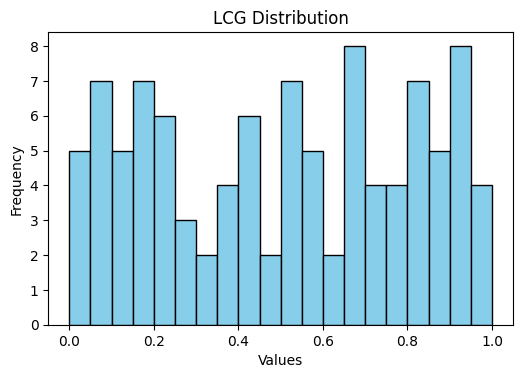

In [5]:
random.histogram(100)

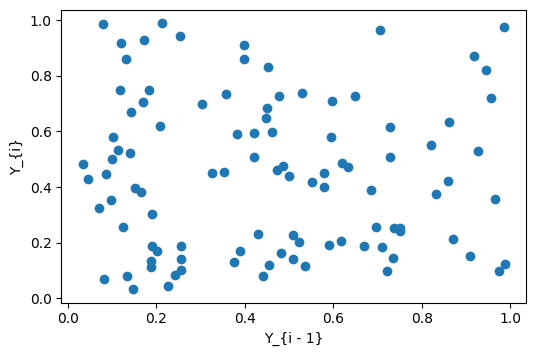

In [6]:
random.scatterplot(100)

But if we don't follow the rules stated above, that is not necissarily the case:

If $c$ and $m$ are not coprime, or $(a - 1)$ doesn't share prime factors with $m$, we get a stepwise linear output (the former leads to greater-than-one spacing, the ladder to correlation between consecutive outputs):

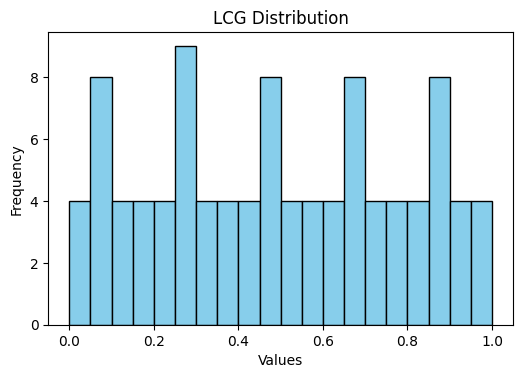

In [7]:
# c and m are not coprime:
random.histogram(100, m = 125, a = 6, c = 5)

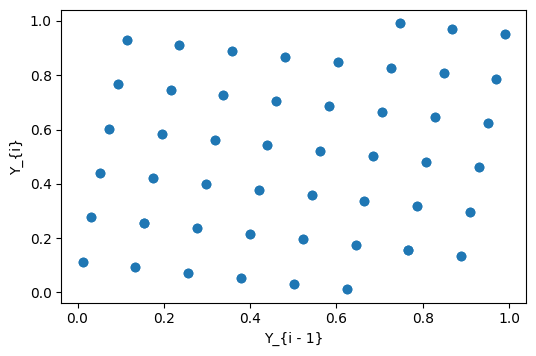

In [8]:
random.scatterplot(100, m = 343, a = 8, c = 7)

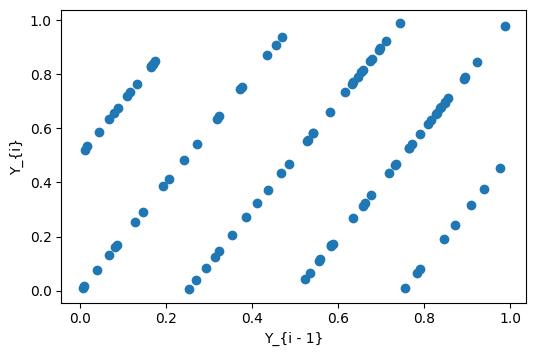

In [9]:
# (a - 1) doesn't share factors with m
random.scatterplot(100, m = 2018, a = 1011, c = 1)

## Fixed point iterations

We occasionally find that the identity of some equation cannot be solved trivialy, but can be put into the form where it is a function of itself:

$$x = g(x)$$

For example, the function $\frac{e^{x} + e^{-x}}{x} = e^{x}$ can be put in the form:

$$x = 1 + e^{-2x}$$

We can then compute a solution by taking some initial guess $x_0$, and then iterating our guesses in the form $x_n = g(x_{n - 1})$. If the magnitude of the derivative of $g(x)$ is less than 1 around the solution (such that we dont overshoot), then we will eventually arrive at the exact solution. We can confrim this condition for the function above since $e^{-2x} > 0 \implies x > 1$, so $g'(x) = -2xe^{-2x} > -2e^{-2} > -1$.

The function coded is as simple as this (though this example would cause infinite recursion):

```python
def fpi(g, x):
    return fpi(g, g(x))
```

The function bellow solves this function recursivly in Python until the error between terms ($x$ and $g(x)$) is less than $10^{-3}$:

In [10]:
g = lambda x: (
    1 + np.exp(-2*x)
)

float(fpi.solve(g))

1.1086385087125783

## Interpolations

It is often the case that given a set of two-dimensional datapoints of the form $(x, y)$, we want to predict the value of $y$ given some $x$ not present in the dataset.

Imagine our data is defined by the underlying function: 

$$f(x) = \frac{1}{e^{-x} + e^{x}} \quad \text{over the interval} \quad -5 \leq x \leq 5$$

The naive approach is to interpolate our data as a set of piecewise functions over some $N$ sampled points, simply connecting the dots; this just consists of finding 
the linear equation $y = \frac{y_{i+1} - y_{i}}{x_{i + 1} - x_{i}}(x - x_i) + y_i$ and casting it over the interval $[x_i, x_{i+1}]$.

Here is an example of evenly-spaced linear interpolations of our equation:

Average error: 0.0185. Max error: 0.0387


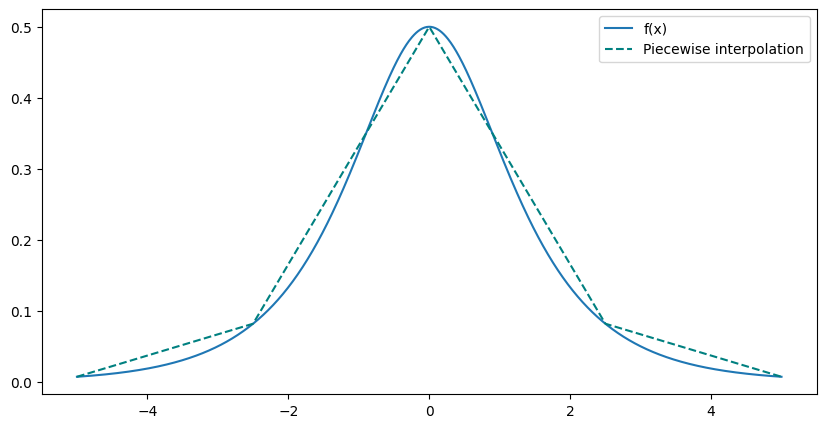

In [11]:
f = lambda x: (
    1 / 
        (np.exp(-x) + np.exp(x)) 
)

# N = 5

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), n = 5, piecewise = True, plot = True)

print(f"Average error: {error["piecewise"][1]:.3g}. Max error: {error["piecewise"][0]:.3g}")

Average error: 0.00965. Max error: 0.0683


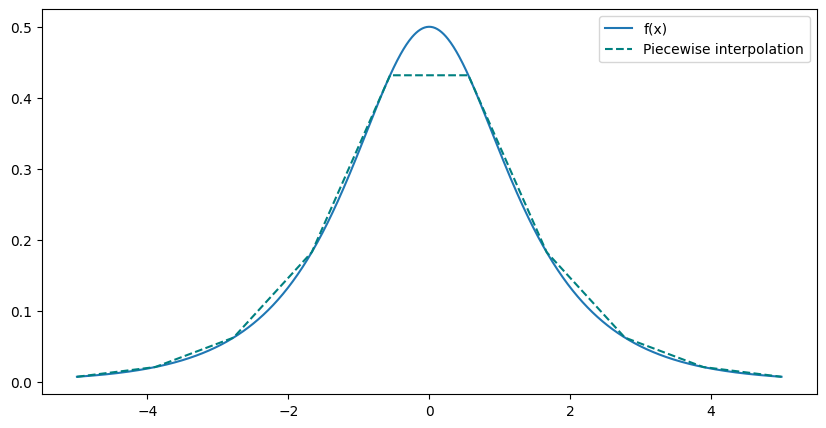

In [12]:
# N = 10

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), n = 10, piecewise = True, plot = True)

print(f"Average error: {error["piecewise"][1]:.3g}. Max error: {error["piecewise"][0]:.3g}")

Average error: 0.00416. Max error: 0.0225


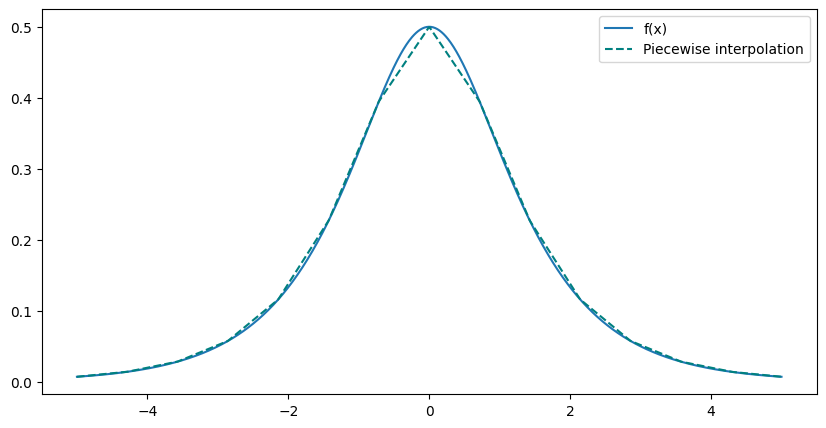

In [13]:
# N = 15

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), n = 15, piecewise = True, plot = True)

print(f"Average error: {error["piecewise"][1]:.3g}. Max error: {error["piecewise"][0]:.3g}")

This is going to be unaccurate for obious reasons. Though the error can only get so high, it will be unaccurate for "swiggly" functions (large magnitude higher-order derivatives), and can actually be computationally expensive for many datapoints.

To acheive smoothness, we can interpolate datapoints into high-order polynomials.

For every set of points $S \subseteq \mathbb{R}^2$, there exists a unqiue function of the oder $|S| - 1$ which passes through every point. The proof isn't needed for the following explanations, but just think of it as: for every data point you add, you need to increase the order of the function by at most one.

One such way to find this unique function is called the Lagrange method. We find our function as:

$$f(x) = y_1L_1 + y_2L_2 + \ldots y_nL_n$$

where $L_i$ is a function that is 1 at $x = x_i$, and $0$ at every other $x_j$. The simplist way to find such a function is by using the form:

$$L_i = \frac{(x - x_1)(x - x_2)\ldots(x - x_{i-1})(x-x_{i + 1})\ldots(x - x_{n-1})(x - x_n)}{(x_i - x_1)(x_i - x_2)\ldots(x_i - x_{i-1})(x_i-x_{i + 1})\ldots(x_i - x_{n-1})(x_i - x_n)}$$

$$L_i = \frac{\prod_{j = 0, \text{ } j \neq i}^{n} (x_i - x_j)}{\prod_{j = 0, \text{ } j \neq i}^{n} (x - x_j)}$$

At any $x = x_j$, one of the terms on top becomes a $0 \rightarrow L_i = 0$; at $x = x_i$, the denominatior equals the numerator, so $L_i = 1$.

In Python, finding our Lagrangian looks like this:

```python
denom = 1
for x_j, _ in points:
    if x_j == x_i:
            continue
        denom *= (x_i - x_j)

    partials = [y_i / denom]

    for root, _ in points:
        if root == x_i:
            continue
        partials = ( # Multiply (x - x_j) against existing partial equation
            [partials[0]] + [partials[i+1] - root*partials[i] for i in range(len(partials)-1)]
            + [-root*partials[-1]]
        )
```
Where partials is the list of coefficients of our lagrangian function in desending order.

This solution is slow, $O(n^2)$, but will ultimatley get us to the unique function $P^{n - 1}(x)$.

We can now use this method to interpolate our inital function:

Average error: 0.0959. Max error: 0.197


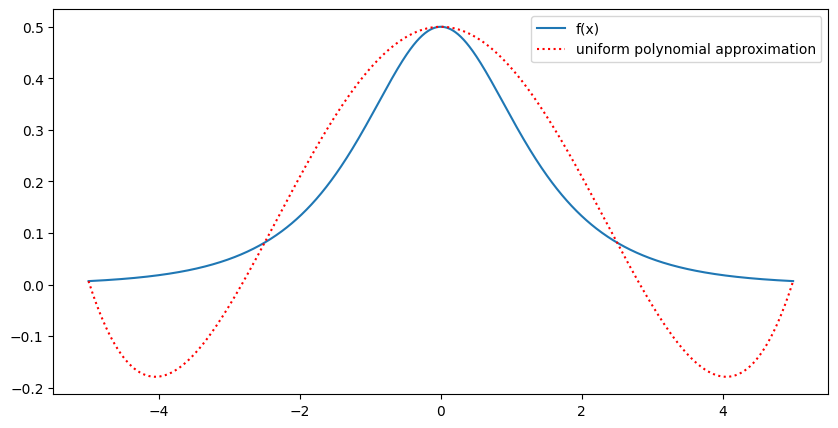

In [14]:
# N = 5

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 5, plot = True, polynomial = True)

print(f"Average error: {error["polynomial"][1]:.3g}. Max error: {error["polynomial"][0]:.3g}")

Average error: 0.0254. Max error: 0.111


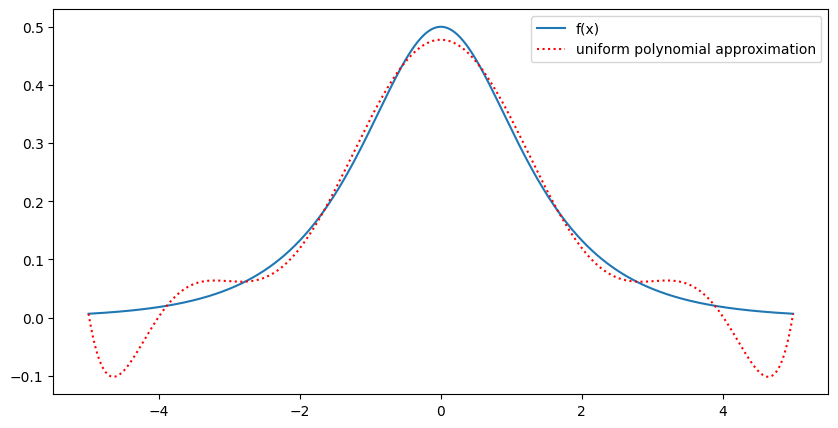

In [15]:
# N = 10

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 10, plot = True, polynomial = True)

print(f"Average error: {error["polynomial"][1]:.3g}. Max error: {error["polynomial"][0]:.3g}")

Average error: 0.0734. Max error: 0.802


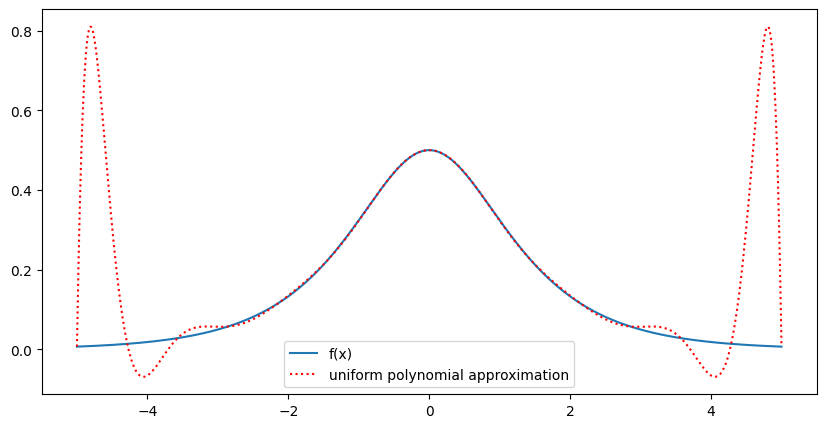

In [16]:
# N = 15

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 15, plot = True, polynomial = True)

print(f"Average error: {error["polynomial"][1]:.3g}. Max error: {error["polynomial"][0]:.3g}")

You can pretty quickly start to see this issue with this approach: using evenly spaced points, our equation will be generally smooth in the middle of our data, but blows up at its endpoints, especially at higher orders.

One solution for this is to cluster our sampled points and the ends using non-uniform distribution. One such distribution that does this is called the Chebyshev distribution, it is defined as follows: 

For $N$ nodes, each $x_i$ can be found as 
$$x_i = \cos\Big(\frac{(2i - 1)\pi}{2N}\Big) \times (b - a) + a$$

This just gets us the cosine distribution over the interval $[-b, a]$ --- the $x$ values of the unit circle as we iterate by equal radians in the first two quadrents for $[-1, 1]$.

Heres a graph of what it looks like: 

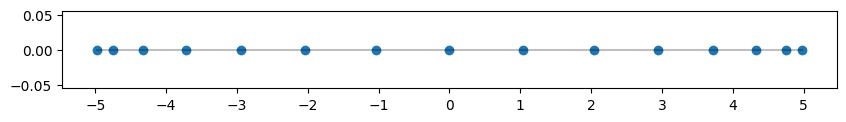

In [17]:
n = 15

points = interp.generate_cheby(lambda x: 0, n, (-5, 5))
cheby_x = [points[i][0] for i in range(n) ]
y = [0] * n

plt.figure(figsize = (10, 1))
plt.plot(cheby_x, y, 'black', alpha = 0.25)
plt.scatter(cheby_x, y, alpha = 1)
plt.xticks(ticks=np.linspace(-5, 5, 11))
plt.show()

You can see this difference in sampling makes a huge impact:

Average error: 0.0712. Max error: 0.14


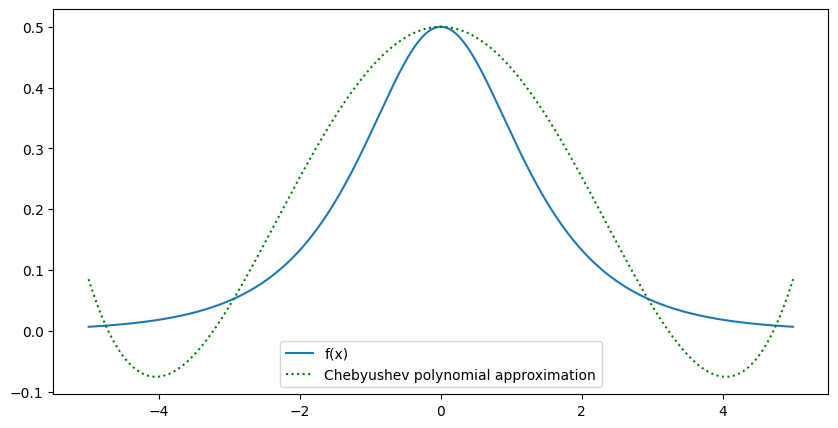

In [18]:
# N = 5

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 5, plot = True, cheby = True)

print(f"Average error: {error["chebyshev"][1]:.3g}. Max error: {error["chebyshev"][0]:.3g}")

Average error: 0.0146. Max error: 0.0576


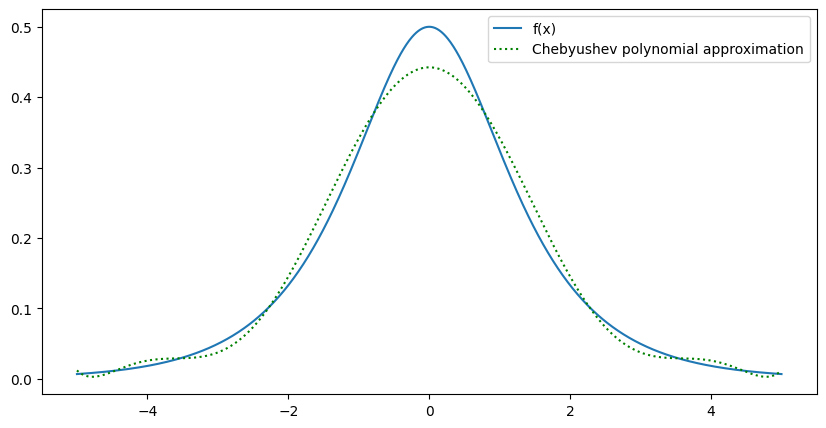

In [19]:
# N = 10

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 10, plot = True, cheby = True)

print(f"Average error: {error["chebyshev"][1]:.3g}. Max error: {error["chebyshev"][0]:.3g}")

Average error: 0.00299. Max error: 0.00616


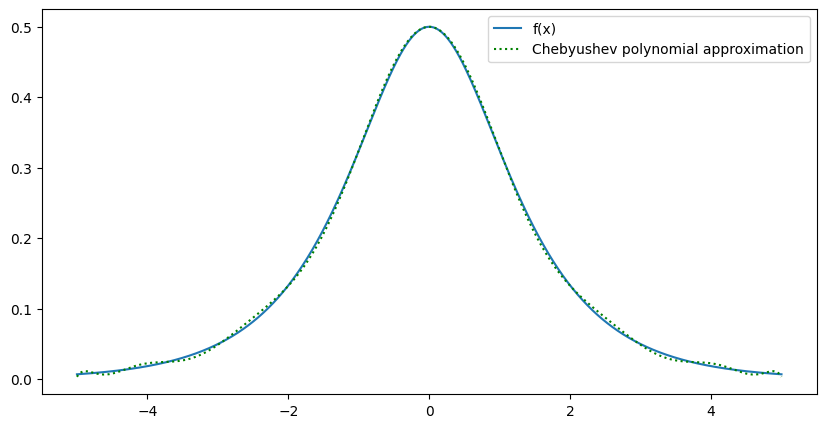

In [26]:
# N = 15

plt.figure(figsize=(10, 5))
error = interp.compare_interpolations(f, (-5, 5), 15, plot = True, cheby = True)

print(f"Average error: {error["chebyshev"][1]:.3g}. Max error: {error["chebyshev"][0]:.3g}")

## Integrals

Often times, even if we have a function which is discrite on all $x$, it does not have a defined integral. The most important example of this is in the equation for normal distribution:

$$\text{pdf}(x) = \frac{1}{\sqrt{2\pi}}e^{-t^2/2}$$

As a norm cdf (used everywhere in stats) is exactly the integral of this function, it is important that we are able to compute an approximation for it (as well as many others).

The first way to go about this is naive, but also most commonly used: take a sample of points across the function, average them and multiply it by the range.

$$\int_a^b f(x) \approx \Delta x (f(x_1) + f(x_2) + \ldots + f(x_n)$$

For $n$ evenly spaced numbers on $[a, b]$

This is called the "midpoint approximation," and is accurate, fast, and practical especially for low-dimension functions.

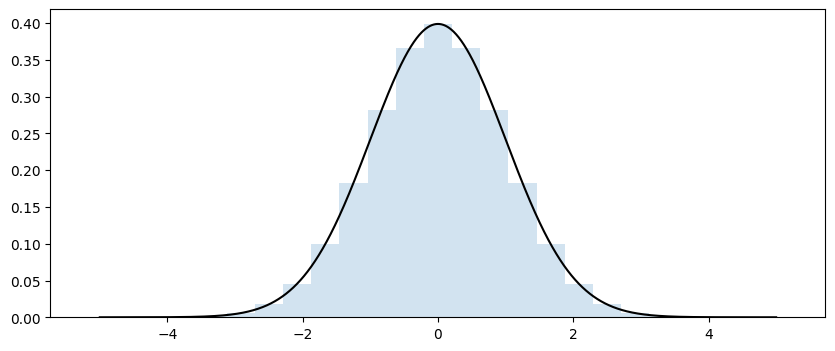

In [21]:
n = 25

pdf = lambda x: (
    (np.exp(-x**2 / 2)) / 
    (np.sqrt(2*np.pi))
)

x = np.linspace(-5, 5, 10_000)
x_sampled = np.linspace(-5, 5, n)

plt.figure(figsize = (10, 4))
plt.plot(x, pdf(x), color = "black")
plt.bar(x_sampled, pdf(x_sampled), alpha = 0.2, width = 10 / (n - 1))
plt.show()

Using it to approximate the cdf (with a lower bound at -5), we get:

In [22]:
cdf_midpoint = lambda x: (
    integrals.midpoint_area(pdf, -5, x, 10_000)
)

float(cdf_midpoint(0))

0.5000494493187186

$\approx 0.5$

Another, more brute-force method, is to approach the problem from a $Monte \text{ } Carlo$ perspective (random sampling). This is especially useful for higher-dimension functions, where integrals are far less trival.

This method consists of populating a space which you know contains the function (or most of it) with random points, and then multiplying the percentage of points lying within/underneath the function by the magnitude of the area. This method works every time, regardless of how complex the function, but has the obious drawback of being inconsistent.

Bellow is a visualization of the approach using the $LCG$ random number generator from before.

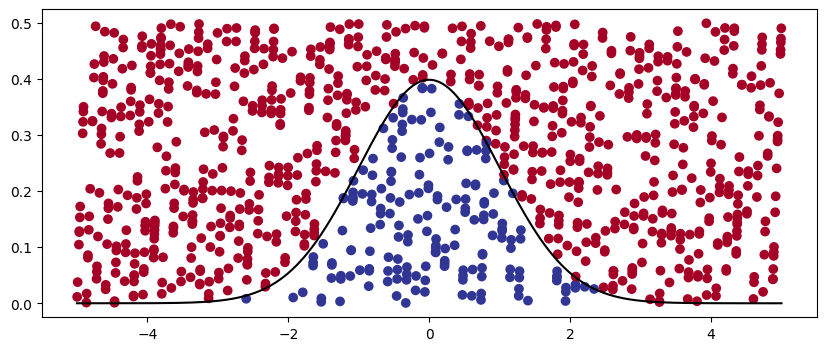

: 

In [ ]:
n = 1000

t = []
y = []
samples = np.zeros(n, dtype = bool)
area = 5

for i in range(n):
    x_i = -5 + random.lcg() * 10
    y_i = random.lcg() * 0.5

    if y_i <= pdf(x_i):
        samples[i] = 1

    t.append(x_i)
    y.append(y_i)

x = np.linspace(-5, 5, 10_000)

plt.figure(figsize = (10, 4))
plt.plot(x, pdf(x), color = "black")
plt.scatter(t, y, c = samples, cmap = 'RdYlBu')
plt.show()

The function below solves for the $\text{cdf}$ using this method.

In [24]:
cdf_monte_carlo = lambda x: (
    integrals.monte_carlo(pdf, -5, x, 10_000)
)

float(
    cdf_monte_carlo(5)
)

1.003882039435337

Sampling from only $10,000$ points, we get a standard deviation of $\approx 1.5\%$, so most Monte Carlo integrations use orders of magnitude more points. (the code block below takes a bit to run)

In [25]:
cdfs = np.zeros(1_000)

for i in range(1_000):
    cdfs[i] = cdf_monte_carlo(5)

print(f"Standard deviation: {(np.std(cdfs) * np.average(cdfs) * 100):.2g}%")

KeyboardInterrupt: 

## Finding Roots

For a variety of reasons in mathematics, we might want to find the roots of a function (or when a function equals any number of interest). There are two main ways of approaching this problem from a computational perspective (assuming you cant solve for them for whatever reason)

The first is known as the bisection method: given two points, which are known to have opposite signs in $f$, take the midpoint and then drop the endpoint with the same ($f$) sign as the midpoint. Then find the midpoint of the midpoint and the remaining starting point, and repeat. This can be acheived recursively simply:

```python
def bisection(f, a, b):
    mid = abs(b - a) + 0.5 * min(a, b)

    if f(a) * f(mid) > 0: # Checks if f(a) and f(mid) are the same sign
        return bisection(f, mid, b)
    else:
        return bisection(f, a, mid)
```

It is essentially just a binary search with an added steps.

Below is an example using this algorithm (using our LCG to find a starting $a$ and $b$) to find where $\text{cdf}(x) = 0.5$ (which we know to be at $0$) stopping when error $\leq 10^{-3}$:

In [ ]:
temp = lambda x: cdf_midpoint(x) - 0.5

integrals.midpoint_iterations = 0

integrals.midpoint_root(temp)

0.0008211457602193229

This takes 10 iterations on average in this case, or more generally $\log_2 N$ iterations, where $N = \frac{(b - a)} {\text{error}}$

In [ ]:
integrals.midpoint_iterations

10

The other method for finding roots is Newton's Method, which takes advantage of the fact that a function in motion tends to stay in motion (hehe get it).

After some initial guess $x_0$, we refine our guess by setting 

$$x_n = x_{n - 1} - \frac{f(x_{n-1})}{f'(x_{n-1})}$$

Essentially taking a linear approximation for the function and then seeing where that linear approximation would equal zero.

For finding the derivative, we simply use the central difference: $f'(x) \approx \frac{f(x + h) - f(x - h)}{2h}$ for small $h$.

Here is an Newton's Method being used to solve the same problem from before.

In [ ]:
integrals.newton_iterations = 0

float(integrals.newton_root(temp))

3363405224.944487

This method only takes 3 iterations in this case, and it is faster in most instances, but has no single method defining the number of iterations it takes.

In [ ]:
integrals.newton_iterations

2

The error is also much lower for Newton's Method, despite the fact that both have the same stopping error, which will in many instances be the case, but is also a symptom of $\text{cdf}$ being linear at $x = 0$.